In [1]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.hyperparameter_search.random_search import OptimalXGBHyperparameterSearch

In [2]:
RANDOM_SEED = 32
# RFE on the phase-3 pool recommends 51 features (get_best_num_features(.005)); see rfe.ipynb
BEST_NUM_FEATS = 51
TARGET = 'target_win'

RANDOM_XGB_PARAMS = {
    # How fast the model learns. The smaller, the more likely to get stuck in local minima, but the larger, the more likely to overshoot the global minima
    'learning_rate': [.03, .05, .1, .15, .2],
    # How deep the tree can be. The deeper, the more likely to overfit and more complex
    'max_depth': [2, 3],
    # The fraction of samples to be used for fitting the individual base learners. 
    # Values lower than 1 make the model more robust by preventing overfitting
    'subsample': [.5, .7, .9],
    # The minimum number of samples required to be at a leaf node. The larger, the more conservative
    'min_child_weight': [10, 20, 50, 100],
    # Minimum loss reduction required to make a split on a leaf node of the tree. Attempts to only split when it makes a significant improvement
    'gamma': [.5, 1, 5, 10, 100],
    # The number of trees to be used in the model. The more, the more likely to overfit
    'n_estimators': [10, 20,30, 40, 50],
    # The number of iterations the model can't improve before stopping
    'early_stopping_rounds': [10, 20, 50],
    # The way the model calculates the importance of each feature. Total gain is the sum of the gain of each feature used in the model
    'importance_type': ['total_gain'],
    # The evaluation metric to be used. AUC measures how well the model is able to distinguish between classes (win or loss)
    'eval_metric': ['auc']
}

RANDOM_SEARCH_PARAMS = dict(
    n_iter=100,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    scoring='roc_auc',
)

BEST_FEATS_FROM_RFE = list(pd.read_csv(
    '../../../../../data/predict_games/model_features_in/rfe_features_kfolds.csv',
    index_col=0
).loc[BEST_NUM_FEATS, :].dropna().values)

MODEL_INPUTS_DF = pd.read_parquet(
    '../../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

MODEL_INPUTS_DF = MODEL_INPUTS_DF.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

np.random.seed(RANDOM_SEED)

In [3]:
# Two-season holdout: train on everything before 2022, use 2022-2023 as the early-stopping
# test slice, and hold out 2024+2025 (the original 3-way split shifted one year forward).
train_df = MODEL_INPUTS_DF[(MODEL_INPUTS_DF['season'] < 2022)]
test_df = MODEL_INPUTS_DF[
    (MODEL_INPUTS_DF['season'] >= 2022) & (MODEL_INPUTS_DF['season'] < 2024)
]
holdout_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] >= 2024].copy()
X_train = train_df[BEST_FEATS_FROM_RFE]
y_train = train_df[TARGET]
X_test = test_df[BEST_FEATS_FROM_RFE]
y_test = test_df[TARGET]
X_holdout = holdout_df[BEST_FEATS_FROM_RFE]
y_holdout = holdout_df[TARGET]

In [4]:
rand_hyperparam_search = OptimalXGBHyperparameterSearch(
    X_train, y_train, X_test, y_test
)

In [5]:
rand_search = rand_hyperparam_search.search(
    RANDOM_XGB_PARAMS, **RANDOM_SEARCH_PARAMS
)

[0]	validation_0-auc:0.63591	validation_1-auc:0.60042
[1]	validation_0-auc:0.66105	validation_1-auc:0.61919
[2]	validation_0-auc:0.67634	validation_1-auc:0.63414
[3]	validation_0-auc:0.68426	validation_1-auc:0.64542
[4]	validation_0-auc:0.68981	validation_1-auc:0.65543
[0]	validation_0-auc:0.63458	validation_1-auc:0.61290
[5]	validation_0-auc:0.69328	validation_1-auc:0.65371
[1]	validation_0-auc:0.66027	validation_1-auc:0.62566
[6]	validation_0-auc:0.69456	validation_1-auc:0.65264
[2]	validation_0-auc:0.67871	validation_1-auc:0.63259
[7]	validation_0-auc:0.69854	validation_1-auc:0.65103
[3]	validation_0-auc:0.68192	validation_1-auc:0.63378
[8]	validation_0-auc:0.70075	validation_1-auc:0.65250
[0]	validation_0-auc:0.62930	validation_1-auc:0.61982
[4]	validation_0-auc:0.68959	validation_1-auc:0.63799
[0]	validation_0-auc:0.60921	validation_1-auc:0.60216
[9]	validation_0-auc:0.70213	validation_1-auc:0.65039
[1]	validation_0-auc:0.65677	validation_1-auc:0.64560
[1]	validation_0-auc:0.63140

[31]	validation_0-auc:0.69024	validation_1-auc:0.65769
[37]	validation_0-auc:0.69380	validation_1-auc:0.65578
[23]	validation_0-auc:0.68459	validation_1-auc:0.65540
[41]	validation_0-auc:0.69646	validation_1-auc:0.66320
[33]	validation_0-auc:0.73175	validation_1-auc:0.65448
[28]	validation_0-auc:0.73104	validation_1-auc:0.64983
[17]	validation_0-auc:0.71694	validation_1-auc:0.65651
[37]	validation_0-auc:0.72007	validation_1-auc:0.65550
[32]	validation_0-auc:0.69115	validation_1-auc:0.65784
[38]	validation_0-auc:0.69413	validation_1-auc:0.65557
[32]	validation_0-auc:0.73275	validation_1-auc:0.64188
[24]	validation_0-auc:0.68591	validation_1-auc:0.65536
[42]	validation_0-auc:0.69688	validation_1-auc:0.66360
[29]	validation_0-auc:0.73145	validation_1-auc:0.64980
[34]	validation_0-auc:0.73293	validation_1-auc:0.65365
[18]	validation_0-auc:0.71786	validation_1-auc:0.65606
[33]	validation_0-auc:0.69212	validation_1-auc:0.65844
[39]	validation_0-auc:0.69452	validation_1-auc:0.65624
[38]	valid

[37]	validation_0-auc:0.73728	validation_1-auc:0.65348
[17]	validation_0-auc:0.70690	validation_1-auc:0.65418
[6]	validation_0-auc:0.67767	validation_1-auc:0.64095
[20]	validation_0-auc:0.71012	validation_1-auc:0.65669
[20]	validation_0-auc:0.69162	validation_1-auc:0.66048
[15]	validation_0-auc:0.68553	validation_1-auc:0.65616
[38]	validation_0-auc:0.71931	validation_1-auc:0.65965
[6]	validation_0-auc:0.67998	validation_1-auc:0.65232
[19]	validation_0-auc:0.69057	validation_1-auc:0.66489
[37]	validation_0-auc:0.71934	validation_1-auc:0.66515
[28]	validation_0-auc:0.71433	validation_1-auc:0.66044
[18]	validation_0-auc:0.70806	validation_1-auc:0.65339
[21]	validation_0-auc:0.71093	validation_1-auc:0.65641
[7]	validation_0-auc:0.68181	validation_1-auc:0.64487
[21]	validation_0-auc:0.69344	validation_1-auc:0.66113
[16]	validation_0-auc:0.68792	validation_1-auc:0.65864
[39]	validation_0-auc:0.72008	validation_1-auc:0.65971
[7]	validation_0-auc:0.68308	validation_1-auc:0.65586
[20]	validatio

[0]	validation_0-auc:0.57271	validation_1-auc:0.56906
[10]	validation_0-auc:0.65302	validation_1-auc:0.63849
[5]	validation_0-auc:0.58980	validation_1-auc:0.57616
[12]	validation_0-auc:0.65136	validation_1-auc:0.63011
[0]	validation_0-auc:0.57723	validation_1-auc:0.56169
[5]	validation_0-auc:0.64556	validation_1-auc:0.62410
[1]	validation_0-auc:0.63140	validation_1-auc:0.61963
[5]	validation_0-auc:0.61846	validation_1-auc:0.59611
[11]	validation_0-auc:0.65302	validation_1-auc:0.63849
[1]	validation_0-auc:0.61597	validation_1-auc:0.59710
[13]	validation_0-auc:0.65136	validation_1-auc:0.63011
[1]	validation_0-auc:0.57940	validation_1-auc:0.56363
[13]	validation_0-auc:0.63760	validation_1-auc:0.62315
[6]	validation_0-auc:0.64556	validation_1-auc:0.62410
[2]	validation_0-auc:0.64369	validation_1-auc:0.62875
[6]	validation_0-auc:0.61846	validation_1-auc:0.59611
[2]	validation_0-auc:0.61718	validation_1-auc:0.59846
[14]	validation_0-auc:0.65136	validation_1-auc:0.63011
[6]	validation_0-auc:0

[4]	validation_0-auc:0.66907	validation_1-auc:0.64142
[0]	validation_0-auc:0.60989	validation_1-auc:0.58858
[1]	validation_0-auc:0.62259	validation_1-auc:0.60785
[7]	validation_0-auc:0.67006	validation_1-auc:0.63883
[2]	validation_0-auc:0.65216	validation_1-auc:0.63357
[5]	validation_0-auc:0.66916	validation_1-auc:0.64057
[2]	validation_0-auc:0.61840	validation_1-auc:0.59922
[1]	validation_0-auc:0.61104	validation_1-auc:0.58861
[8]	validation_0-auc:0.67125	validation_1-auc:0.64103
[9]	validation_0-auc:0.66652	validation_1-auc:0.64082
[3]	validation_0-auc:0.65667	validation_1-auc:0.63966
[3]	validation_0-auc:0.62948	validation_1-auc:0.61304
[6]	validation_0-auc:0.67023	validation_1-auc:0.64260
[2]	validation_0-auc:0.61634	validation_1-auc:0.59229
[9]	validation_0-auc:0.66945	validation_1-auc:0.64069
[4]	validation_0-auc:0.66186	validation_1-auc:0.64475
[4]	validation_0-auc:0.62631	validation_1-auc:0.60558
[7]	validation_0-auc:0.66919	validation_1-auc:0.64015
[3]	validation_0-auc:0.62339

...

[36]	validation_0-auc:0.73936	validation_1-auc:0.65424


[37]	validation_0-auc:0.74067	validation_1-auc:0.65586


[38]	validation_0-auc:0.74125	validation_1-auc:0.65587


[39]	validation_0-auc:0.74225	validation_1-auc:0.65688




Best parameters found:  {'subsample': 0.9, 'n_estimators': 40, 'min_child_weight': 50, 'max_depth': 3, 'learning_rate': 0.2, 'importance_type': 'total_gain', 'gamma': 5, 'eval_metric': 'auc', 'early_stopping_rounds': 50}


Best score found:  0.6872274181873828


Best Selected Features:  ['is_home_target', 'def_target_rushing_yards_cumulative_average_rank', 'target_def_cumulative_avg_points_allowed_rank', 'opp_def_cumulative_avg_points_allowed_rank', 'def_target_run_right_end_yards_per_attempt_garbage_trailing_cumulative_average_rank', 'off_opp_early_down_success_rate_competitive_cumulative_average_rank', 'opp_off_cumulative_avg_score_rank', 'def_opp_run_right_end_yards_per_attempt_garbage_trailing_cumulative_average_rank', 'target_off_cumulative_avg_score_rank', 'off_target_epa_per_play_garbage_leading_cumulative_average_rank', 'off_opp_success_rate_competitive_cumulative_average_rank', 'off_opp_epa_per_play_competitive_cumulative_average_rank', 'def_target_run_right_end_explosive_ra

In [6]:
# view all the scores from the search
rand_search.cv_results_

{'mean_fit_time': array([0.22057719, 0.25654521, 0.22750454, 0.21889191, 0.26551571,
        0.08718038, 0.12297845, 0.12259026, 0.21453371, 0.18280888,
        0.08356261, 0.08908806, 0.20376134, 0.18171144, 0.24993458,
        0.14483442, 0.13309746, 0.14152923, 0.13978524, 0.08481627,
        0.08858986, 0.1346663 , 0.18215146, 0.18638554, 0.18448701,
        0.26754436, 0.14029098, 0.13467803, 0.17226553, 0.18543544,
        0.1785428 , 0.26206231, 0.13010731, 0.22403603, 0.08986096,
        0.08649659, 0.13236232, 0.16987972, 0.09983859, 0.14044223,
        0.21610904, 0.2554462 , 0.10727582, 0.12107253, 0.18669353,
        0.08797803, 0.08687282, 0.12411971, 0.16728024, 0.26652331,
        0.17558684, 0.09710798, 0.26883268, 0.0866663 , 0.22035074,
        0.13816609, 0.26390333, 0.08941388, 0.21588664, 0.11131997,
        0.18499227, 0.16303253, 0.0866642 , 0.09196315, 0.13851361,
        0.17090602, 0.11507826, 0.13297062, 0.17099171, 0.25751281,
        0.17993593, 0.13531389,

<Axes: >

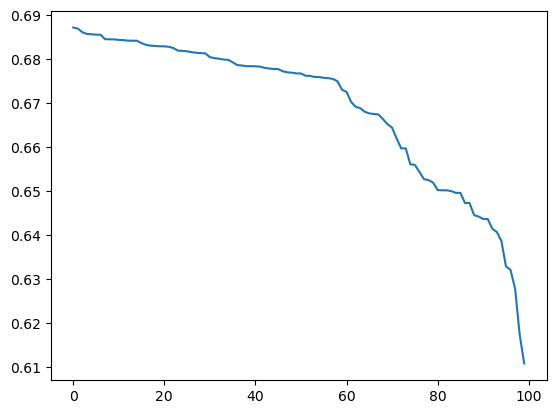

In [7]:
# Graph the search results. Make the index the rank of the score
# another column for the mean test score
rand_search_results = pd.DataFrame(rand_search.cv_results_)
rand_search_results['rank_test_score'] = rand_search_results['rank_test_score']
rand_search_results['mean_test_score'] = rand_search_results['mean_test_score']
rand_search_results = rand_search_results.sort_values(by='rank_test_score', ascending=True)
rand_search_results = rand_search_results.reset_index(drop=True)
rand_search_results['mean_test_score'].plot()

In [8]:
# What are the grid search params for the top 5 scores?
rand_search_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_importance_type,...,param_early_stopping_rounds,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.227505,0.006939,0.004035,0.001412,0.9,40,50,3,0.2,total_gain,...,50,"{'subsample': 0.9, 'n_estimators': 40, 'min_ch...",0.685417,0.675906,0.684265,0.693255,0.697295,0.687227,0.007455,1
1,0.222718,0.011025,0.002888,0.000042,0.9,40,20,3,0.05,total_gain,...,20,"{'subsample': 0.9, 'n_estimators': 40, 'min_ch...",0.687045,0.679747,0.681051,0.691907,0.695095,0.686969,0.005960,2
2,0.132971,0.004422,0.002666,0.000028,0.9,20,20,3,0.2,total_gain,...,10,"{'subsample': 0.9, 'n_estimators': 20, 'min_ch...",0.686011,0.678884,0.679953,0.690635,0.695210,0.686138,0.006220,3
3,0.207760,0.009698,0.002758,0.000045,0.9,40,100,2,0.1,total_gain,...,20,"{'subsample': 0.9, 'n_estimators': 40, 'min_ch...",0.681182,0.683964,0.676875,0.690184,0.696604,0.685762,0.006933,4
4,0.262062,0.010011,0.004779,0.003006,0.7,50,20,3,0.1,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 50, 'min_ch...",0.677475,0.687404,0.682975,0.685120,0.695410,0.685677,0.005875,5


In [9]:
# save the json of the best model
best_model = rand_search.best_estimator_
best_model.save_model(
    os.path.join(module_path, 'models', 'best_random_xgb_model.json')
)

In [10]:
# What is the score on the holdout set?
best_model.score(X_holdout, y_holdout)

0.6488970588235294

In [11]:
holdout_df.loc[:, 'preds'] = best_model.predict_proba(X_holdout)[:, 1]

In [12]:
# Show the predictions for the holdout set
results_df = holdout_df[
    ['game_id', 'week', 'target_team', 'opp_team', 'target_win', 'preds']
].copy()
results_df.sort_values(by='game_id', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,game_id,week,target_team,opp_team,target_win,preds
0,2024_01_ARI_BUF,1,ARI,BUF,0,0.256308
1,2024_01_ARI_BUF,1,BUF,ARI,1,0.744540
2,2024_01_BAL_KC,1,KC,BAL,1,0.538413
3,2024_01_BAL_KC,1,BAL,KC,0,0.426731
4,2024_01_CAR_NO,1,CAR,NO,0,0.262019
...,...,...,...,...,...,...
1083,2025_18_SEA_SF,18,SF,SEA,0,0.543504
1084,2025_18_TEN_JAX,18,JAX,TEN,1,0.756962
1085,2025_18_TEN_JAX,18,TEN,JAX,0,0.206712
1086,2025_18_WAS_PHI,18,PHI,WAS,0,0.711660


week
1     0.877930
2     0.672852
3     0.515625
4     0.666992
5     0.452806
6     0.726516
7     0.817778
8     0.733650
9     0.796671
10    0.637755
11    0.746730
12    0.744856
13    0.757812
14    0.790123
15    0.822266
16    0.641602
17    0.656250
18    0.632812
dtype: float64

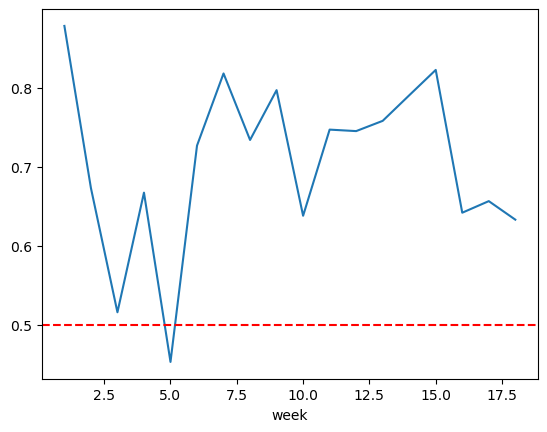

In [13]:
# get the AUROC score by week
weekly_scores = holdout_df.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

In [14]:
# for each game_id, only keep the higher prediction
higher_preds = holdout_df.groupby('game_id').apply(
    lambda x: x.loc[x['preds'].idxmax(), :],
    include_groups=False
)
higher_preds.reset_index(drop=True, inplace=True)

week
1     0.760000
2     0.445887
3     0.500000
4     0.606061
5     0.578125
6     0.386905
7     0.793651
8     0.673684
9     0.744444
10    0.421053
11    0.666667
12    0.611842
13    0.473958
14    0.721429
15    0.651042
16    0.643725
17    0.722222
18    0.512500
dtype: float64

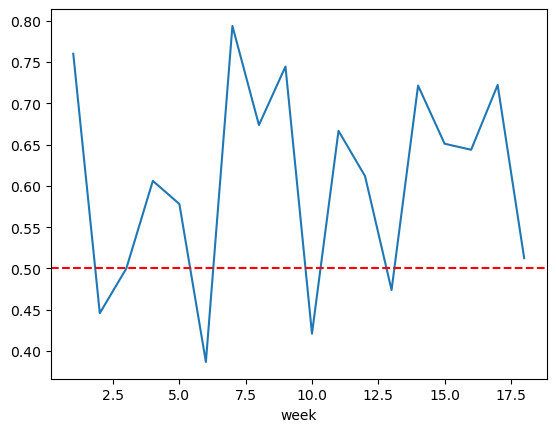

In [15]:
# get the AUROC score by week
weekly_scores = higher_preds.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

## How good are the model's *confident* predictions?

AUROC only measures **ranking** (can the model sort winners above losers?). It says
nothing about whether a 0.80 prediction is actually right ~80% of the time. The cells
below answer "when the model has a strong prediction, how well does it predict?" using:

1. **Brier score & log loss** — residual-based metrics that penalize overconfidence.
2. **Confidence-bucketed accuracy** — the direct answer: how often the favored team wins,
   grouped by how sure the model was.
3. **Reliability diagram** — visual calibration check (predicted prob vs observed win rate).

Note: `holdout_df` has two rows per `game_id` (one per team). Brier/log loss are computed
on all rows consistently; the bucketed-accuracy table uses the one-row-per-game `higher_preds`
frame so each game is counted once.

In [16]:
# Residual-based metrics. Unlike AUROC, these penalize confident-and-wrong predictions.
from sklearn.metrics import brier_score_loss, log_loss

brier = brier_score_loss(holdout_df['target_win'], holdout_df['preds'])
ll = log_loss(holdout_df['target_win'], holdout_df['preds'])
print(f"Brier score: {brier:.4f}  (lower is better; 0.25 = coin flip)")
print(f"Log loss:    {ll:.4f}  (lower is better; punishes confident-and-wrong hardest)")

Brier score: 0.2206  (lower is better; 0.25 = coin flip)
Log loss:    0.6319  (lower is better; punishes confident-and-wrong hardest)


In [17]:
# Confidence-bucketed accuracy: the direct answer to "when the model is confident, is it right?"
# On higher_preds, `preds` is the model's confidence in its pick (0.5-1.0) and
# target_win == 1 means the favored team actually won.
higher_preds['confidence'] = higher_preds['preds']
higher_preds['bucket'] = pd.cut(
    higher_preds['confidence'], bins=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
)

confidence_summary = higher_preds.groupby('bucket', observed=True).agg(
    n_games=('target_win', 'size'),
    pick_accuracy=('target_win', 'mean'),   # how often the favored team won
    avg_confidence=('confidence', 'mean'),  # what the model claimed
)
# Positive gap = overconfident (claimed more than it delivered)
confidence_summary['calibration_gap'] = (
    confidence_summary['avg_confidence'] - confidence_summary['pick_accuracy']
)
confidence_summary

,n_games,pick_accuracy,avg_confidence,calibration_gap
bucket,,,,
"(0.5, 0.6]",250,0.588000,0.551898,-0.036102
"(0.6, 0.7]",190,0.705263,0.642558,-0.062706
"(0.7, 0.8]",65,0.846154,0.729878,-0.116276


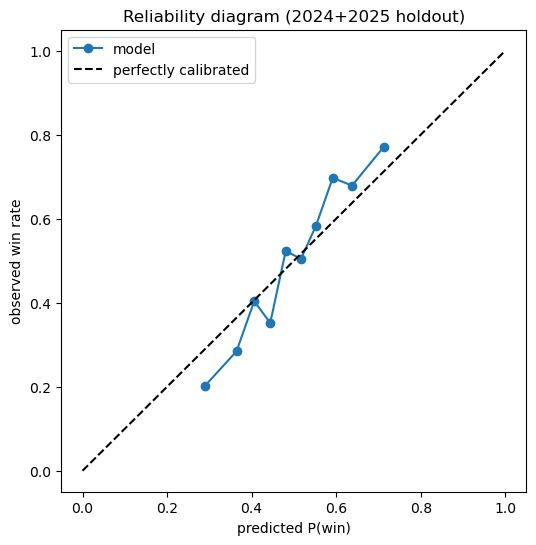

In [18]:
# Reliability diagram: are the probabilities trustworthy?
# Points on the diagonal = perfectly calibrated. Below the diagonal on the right
# side = the model is overconfident when bullish.
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    holdout_df['target_win'], holdout_df['preds'], n_bins=10, strategy='quantile'
)
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='model')
plt.plot([0, 1], [0, 1], 'k--', label='perfectly calibrated')
plt.xlabel('predicted P(win)')
plt.ylabel('observed win rate')
plt.title('Reliability diagram (2024+2025 holdout)')
plt.legend()
plt.show()

## Does a wider home-vs-away gap mean better predictions?

Each game has two predictions: `P(home wins)` from the home-perspective row and
`P(away wins)` from the away-perspective row. The **gap** between them is a stronger
confidence signal than `max(pred)` alone — it uses *both* perspectives. A wide gap
means the two views agree strongly on a winner; a narrow gap means the model is torn.

Hypothesis: when the gap is wide, accuracy should be higher. We pivot the two rows onto
one row per game (via `is_home_target`), define the model's pick as whichever side has
the higher probability, and bucket accuracy by gap width (quintiles, so every bin is
populated).

In [19]:
# Pivot the two perspectives of each game onto one row (is_home_target: 1 = home, 0 = away)
game_view = holdout_df.pivot_table(
    index='game_id', columns='is_home_target', values=['preds', 'target_win'], aggfunc='first'
).dropna()

games = pd.DataFrame({
    'home_pred': game_view[('preds', 1)],
    'away_pred': game_view[('preds', 0)],
    'home_won':  game_view[('target_win', 1)].astype(int),
})
games['gap']           = games['home_pred'] - games['away_pred']   # >0 leans home, <0 leans away
games['abs_gap']       = games['gap'].abs()                        # strength of the lean
games['pred_home_win'] = games['home_pred'] > games['away_pred']
games['correct']       = games['pred_home_win'] == (games['home_won'] == 1)

# Bucket by gap width (quintiles) and measure accuracy in each
games['gap_quintile'] = pd.qcut(games['abs_gap'], 5)
gap_summary = games.groupby('gap_quintile', observed=True).agg(
    n_games=('correct', 'size'),
    mean_abs_gap=('abs_gap', 'mean'),
    accuracy=('correct', 'mean'),
)
print(f"Overall correlation(abs_gap, correct): {games['abs_gap'].corr(games['correct'].astype(int)):.3f}")
gap_summary

Overall correlation(abs_gap, correct): 0.195


,n_games,mean_abs_gap,accuracy
gap_quintile,,,
"(0.0012300000000000002, 0.0656]",109,0.034998,0.532110
"(0.0656, 0.14]",109,0.106085,0.596330
"(0.14, 0.22]",108,0.179354,0.703704
"(0.22, 0.325]",109,0.272923,0.688073
"(0.325, 0.599]",109,0.412457,0.779817


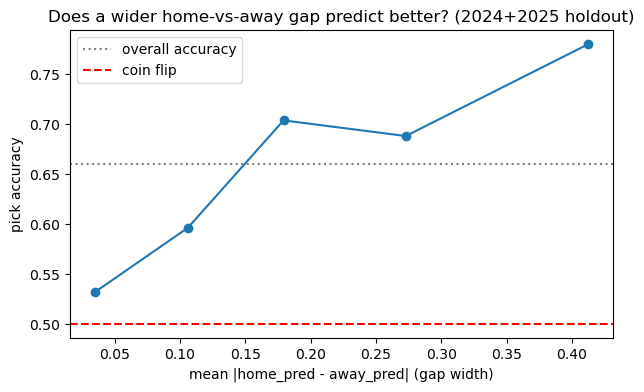

In [20]:
# Visualize the hypothesis: accuracy should rise as the home-vs-away gap widens
plt.figure(figsize=(7, 4))
plt.plot(gap_summary['mean_abs_gap'], gap_summary['accuracy'], marker='o')
plt.axhline(y=games['correct'].mean(), color='gray', linestyle=':', label='overall accuracy')
plt.axhline(y=0.5, color='r', linestyle='--', label='coin flip')
plt.xlabel('mean |home_pred - away_pred| (gap width)')
plt.ylabel('pick accuracy')
plt.title('Does a wider home-vs-away gap predict better? (2024+2025 holdout)')
plt.legend()
plt.show()